Historical VaR (95%) and CVaR

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_path="../data/raw"
processed_path="../data/processed"
clean_nav=pd.read_csv(os.path.join(processed_path,"clean_nav.csv"))

In [3]:
nav_df=clean_nav.copy()
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav_df["return"]=nav_df.groupby('amfi_code')["nav"].pct_change()
nav_df.head()

,amfi_code,date,nav,return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547


In [5]:
var_cvar = []
for scheme, group in nav_df.groupby('amfi_code'):
    returns=group['return'].dropna()
    var_95 = returns.quantile(0.05) 
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar.append([scheme, var_95, cvar_95])

    var_cvar_report = pd.DataFrame( var_cvar, columns=['amfi_code', 'VaR_95', 'CVaR_95'] )
var_cvar_report.to_csv("../reports/var_cvar_report.csv",index=False)

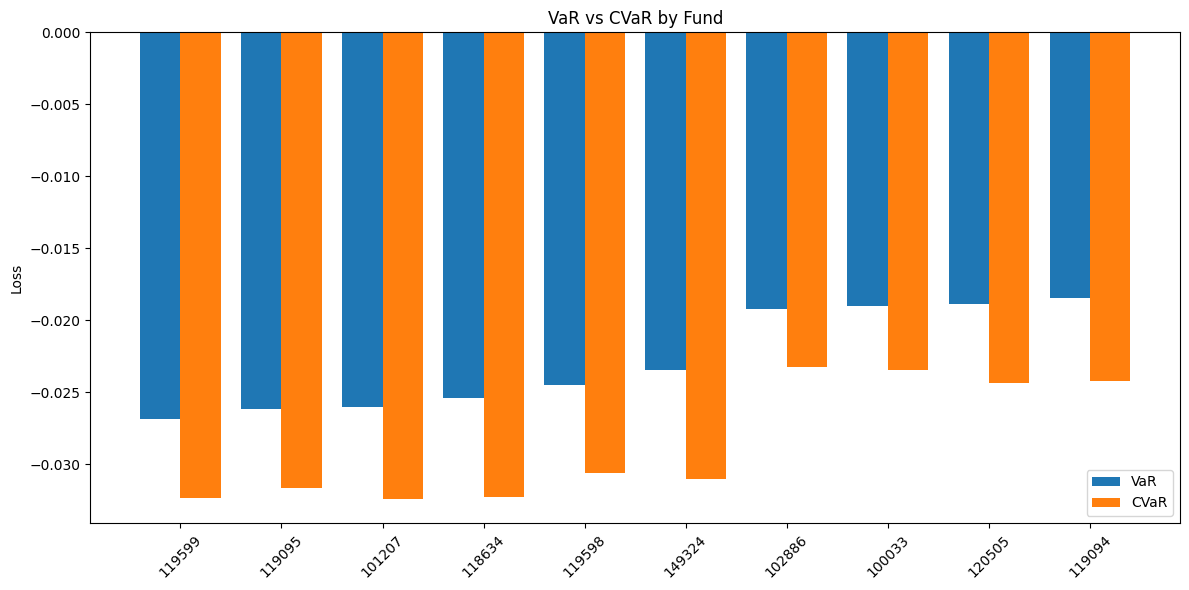

In [6]:
top10 = (
    var_cvar_report
    .sort_values('VaR_95')
    .head(10)
)

plt.figure(figsize=(12,6))

x = range(len(top10))

plt.bar(
    [i-0.2 for i in x],
    top10['VaR_95'],
    width=0.4,
    label='VaR'
)

plt.bar(
    [i+0.2 for i in x],
    top10['CVaR_95'],
    width=0.4,
    label='CVaR'
)

plt.xticks(
    x,
    top10['amfi_code'].astype(str),
    rotation=45
)

plt.title("VaR vs CVaR by Fund")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

90-Day Rolling Sharpe Ratio

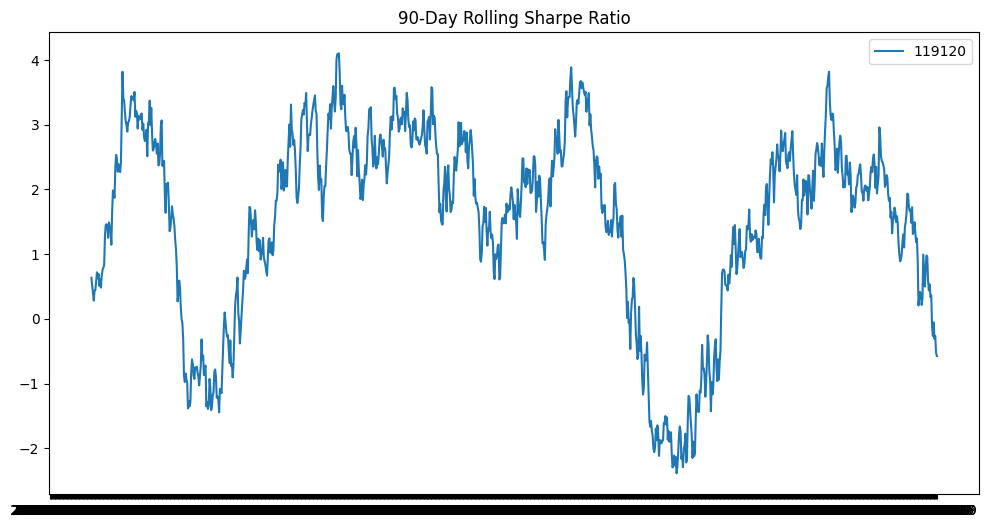

In [7]:
top5 = clean_nav['amfi_code'].unique()[:5] 
plt.figure(figsize=(12,6)) 
for scheme in top5: 
    temp = clean_nav[ clean_nav['amfi_code'] == scheme ].copy() 
    temp['return'] = temp['nav'].pct_change() 
    temp['rolling_sharpe'] = ( temp['return'].rolling(90).mean() / temp['return'].rolling(90).std() ) * np.sqrt(252) 
plt.plot( temp['date'], temp['rolling_sharpe'], label=scheme ) 
plt.legend() 
plt.title("90-Day Rolling Sharpe Ratio") 
plt.savefig("rolling_sharpe_chart.png") 
plt.show()

Investor Cohort Analysis


In [11]:
cohort_df = pd.read_csv(os.path.join(processed_path,"clean_transactions.csv"))
cohort_df['transaction_date'] = pd.to_datetime(
    cohort_df['transaction_date']
)

cohort_df['transaction_year'] = (
    cohort_df['transaction_date'].dt.year
)


first_txn_year = (
    cohort_df.groupby('investor_id')
    ['transaction_year']
    .min()
)

cohort_df['cohort_year'] = (
    cohort_df['investor_id']
    .map(first_txn_year)
)
print(cohort_df.head(5))

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  transaction_year  cohort_year  
0          UPI   Verified        

Average SIP Amount by Cohort

In [12]:
sip_avg = (
    cohort_df[
        cohort_df['transaction_type'] == 'SIP'
    ]
    .groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index()
)

sip_avg.columns = [
    'cohort_year',
    'avg_sip_amount'
]

Total Invested Amount

In [13]:
total_invested = (
    cohort_df
    .groupby('cohort_year')['amount_inr']
    .sum()
    .reset_index()
)

total_invested.columns = [
    'cohort_year',
    'total_invested'
]

Top Fund Preference

In [15]:
top_fund = (
    cohort_df
    .groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund
    .sort_values(
        ['cohort_year','count'],
        ascending=[True,False]
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

In [17]:
cohort_report = (
    sip_avg
    .merge(total_invested,
           on='cohort_year')
    .merge(
        top_fund[
            ['cohort_year','amfi_code']
        ],
        on='cohort_year'
    )
)

cohort_report.rename(
    columns={
        'amfi_code':
        'top_fund_preference'
    },
    inplace=True
)

print(cohort_report)

   cohort_year  avg_sip_amount  total_invested  top_fund_preference
0         2024    10996.885825      3491125187               148568
1         2025    13505.209581        30455243               119599


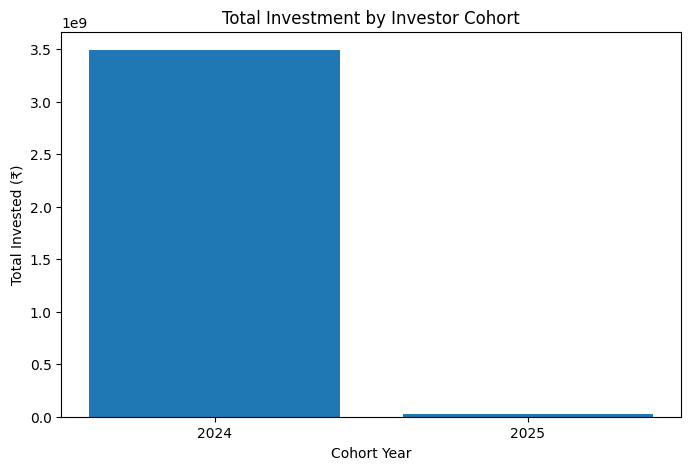

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    cohort_report['cohort_year'].astype(str),
    cohort_report['total_invested']
)

plt.title(
    "Total Investment by Investor Cohort"
)
plt.xlabel("Cohort Year")
plt.ylabel("Total Invested (₹)")
plt.show()

# Advanced Insights

1. The 2024 cohort was the highest investing group with total investments of ₹349.11 Cr, significantly higher than the 2025 cohort (₹3.05 Cr).

2. The 2025 cohort recorded a higher average SIP amount (₹13,505) than the 2024 cohort (₹10,997).

3. Fund 148568 was the most preferred fund among 2024 investors, while Fund 119599 was preferred by the 2025 cohort.

4. Investment activity is heavily concentrated in the 2024 cohort, contributing the majority of total investments.

5. Despite lower total investments, the 2025 cohort shows stronger SIP participation, indicating promising future growth.

SIP Continuity Analysis

In [20]:
clean_transactions=pd.read_csv(os.path.join(processed_path,"clean_transactions.csv"))
sip_df = clean_transactions[
    clean_transactions['transaction_type'] == 'SIP'
].copy()
sip_df['transaction_date'] = pd.to_datetime(
    sip_df['transaction_date']
)

In [21]:
sip_df = sip_df.sort_values(
    ['investor_id', 'transaction_date']
)
sip_df['gap_days'] = (
    sip_df.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [23]:
continuity = (
    sip_df.groupby('investor_id')
    .agg(
        sip_count=('transaction_date', 'count'),
        avg_gap=('gap_days', 'mean')
    )
    .reset_index()
)
continuity = continuity[
    continuity['sip_count'] >= 6
]
continuity['status'] = np.where(
    continuity['avg_gap'] > 35,
    'At-Risk',
    'Active'
)
print(continuity.head())

   investor_id  sip_count    avg_gap   status
3    INV000004          6  85.400000  At-Risk
7    INV000008          6  70.400000  At-Risk
9    INV000010          6  64.800000  At-Risk
10   INV000011          7  40.166667  At-Risk
11   INV000012          8  57.000000  At-Risk


In [24]:
total = len(continuity)

at_risk = len(
    continuity[
        continuity['status'] == 'At-Risk'
    ]
)

continuity_rate = (
    (total - at_risk) / total
) * 100

print(f"Continuity Rate: {continuity_rate:.2f}%")

Continuity Rate: 2.20%


### SIP Continuity Insight

Only 2.20% of investors maintained regular SIP continuity, while the majority were classified as At-Risk due to gaps greater than 35 days between SIP transactions.

## Simple Fund Recommender

In [25]:
clean_performance=pd.read_csv(os.path.join(processed_path,"clean_performance.csv"))
def recommend_funds(risk_appetite):

    recommendations = (
        clean_performance[
            clean_performance['risk_grade']
            .str.lower()
            ==
            risk_appetite.lower()
        ]
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            'fund_house',
            'sharpe_ratio',
            'risk_grade'
        ]
    ]

In [26]:
risk = input(
    "Enter Risk Appetite (Low/Moderate/High): "
)

print(
    recommend_funds(risk)
)

                  fund_house  sharpe_ratio risk_grade
14       ICICI Prudential MF          7.68        Low
23         Kotak Mahindra MF          6.18        Low
30  Aditya Birla Sun Life MF          5.14        Low


### Fund Recommendation Engine

A simple recommendation engine was developed using risk-adjusted performance. Based on the investor's risk appetite, the model recommends the top 3 mutual funds with the highest Sharpe Ratio within the selected risk category.

Sector HHI concentration 

In [30]:
fund_master=pd.read_csv(os.path.join(raw_path,"01_fund_master.csv"))
portfolio_df=pd.read_csv(os.path.join(raw_path,"09_portfolio_holdings.csv"))

In [31]:
equity_funds = fund_master[
    fund_master['category'] == 'Equity'
]

equity_portfolio = portfolio_df.merge(
    equity_funds[['amfi_code']],
    on='amfi_code',
    how='inner'
)

In [32]:
equity_portfolio['weight_decimal'] = (
    equity_portfolio['weight_pct'] / 100
)

equity_portfolio['weight_sq'] = (
    equity_portfolio['weight_decimal'] ** 2
)

hhi_report = (
    equity_portfolio
    .groupby('amfi_code')['weight_sq']
    .sum()
    .reset_index()
)

hhi_report.columns = [
    'amfi_code',
    'HHI'
]

print(hhi_report.head())

   amfi_code       HHI
0     100016  0.139534
1     100033  0.147592
2     101206  0.129332
3     101207  0.200700
4     102885  0.174709


In [33]:
hhi_report = hhi_report.sort_values(
    'HHI',
    ascending=False
)

print(hhi_report.head(10))

    amfi_code       HHI
11     119092  0.206448
3      101207  0.200700
18     119599  0.174751
4      102885  0.174709
7      118632  0.168298
29     148568  0.167930
21     120505  0.157570
22     120506  0.153794
27     125498  0.152414
23     120841  0.149680


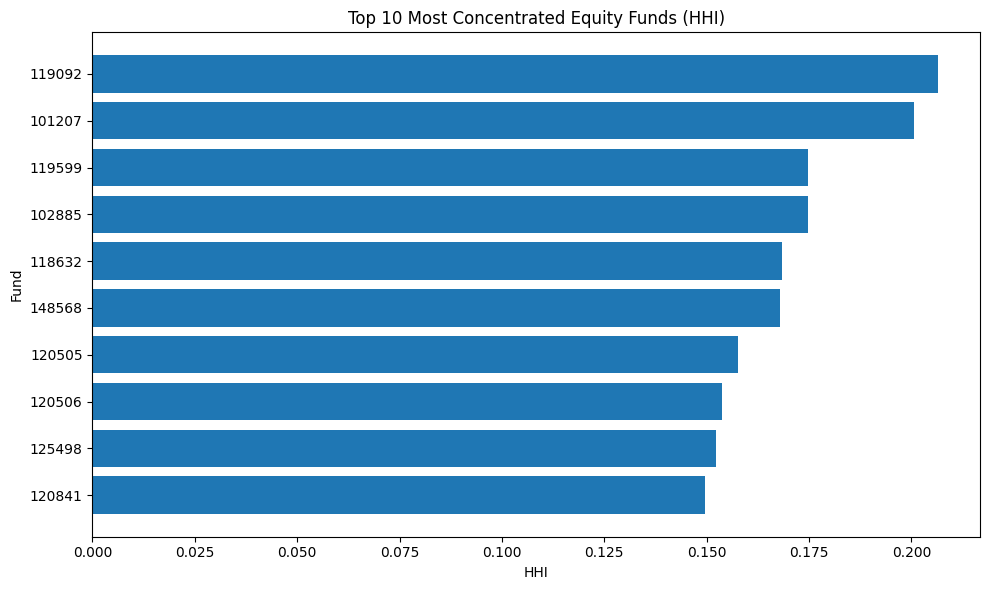

In [34]:
top10 = hhi_report.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['amfi_code'].astype(str),
    top10['HHI']
)

plt.title(
    'Top 10 Most Concentrated Equity Funds (HHI)'
)

plt.xlabel('HHI')
plt.ylabel('Fund')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Sector HHI Concentration Insights

1. Fund 119092 recorded the highest HHI (~0.21), making it the most concentrated equity fund in the portfolio.

2. Funds 101207 and 119599 also exhibited high HHI values (>0.17), indicating significant exposure to a limited number of sectors.

3. Most equity funds have HHI values between 0.15 and 0.21, suggesting moderate sector concentration rather than broad diversification.

4. Higher HHI funds may deliver strong returns when their dominant sectors perform well but are more vulnerable to sector-specific downturns.

5. Funds with lower HHI values, such as 120841 and 125498, are relatively more diversified and may provide better risk distribution across sectors.

In [35]:
hhi_report.to_csv(
    "sector_hhi_report.csv",
    index=False
)